<a href="https://colab.research.google.com/github/hrishabhxcode/Machine-Learning/blob/main/Multiple_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline


In [20]:
df_index = pd.read_csv('Dataset (1).csv')

In [21]:
df_index.head()

,Year,Month,Interest_Rate,Unemployment_Rate,Index_Price
0,2020,12,5.14,8.20,96.22
1,2003,4,1.56,13.95,89.12
2,2000,3,3.95,8.90,70.59
3,2023,8,9.86,2.74,83.50
4,2008,7,8.16,8.60,86.75


In [23]:
df_index.drop(columns=["Year","Month"],axis =1,inplace = True)


In [25]:
df_index.head()

,Interest_Rate,Unemployment_Rate,Index_Price
0,5.14,8.20,96.22
1,1.56,13.95,89.12
2,3.95,8.90,70.59
3,9.86,2.74,83.50
4,8.16,8.60,86.75


In [26]:
df_index.isnull().sum()

,0
Interest_Rate,0
Unemployment_Rate,0
Index_Price,0


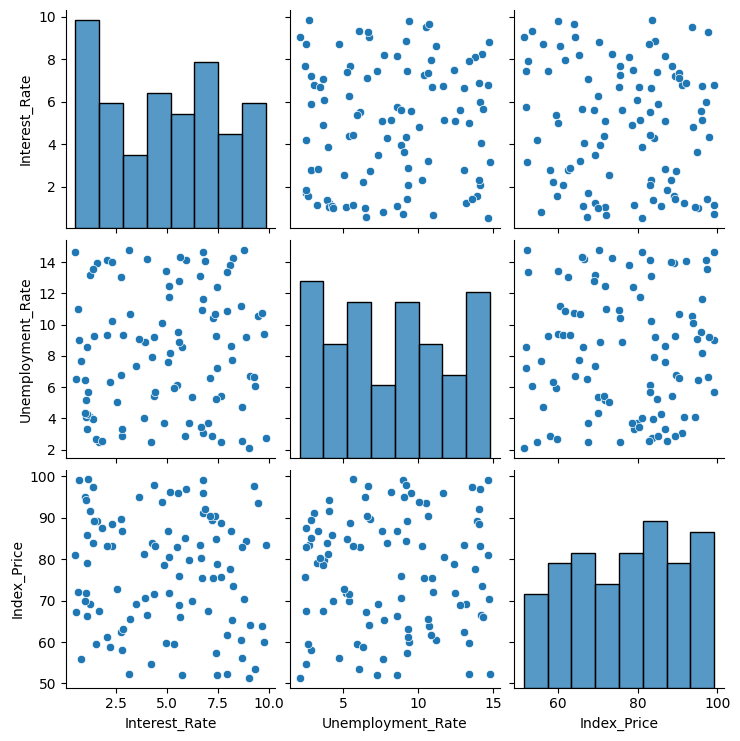

In [27]:
##Visualization
import seaborn as sns
sns.pairplot(df_index)

In [28]:
df_index.corr()

,Interest_Rate,Unemployment_Rate,Index_Price
Interest_Rate,1.000000,0.061721,-0.112839
Unemployment_Rate,0.061721,1.000000,0.015211
Index_Price,-0.112839,0.015211,1.000000


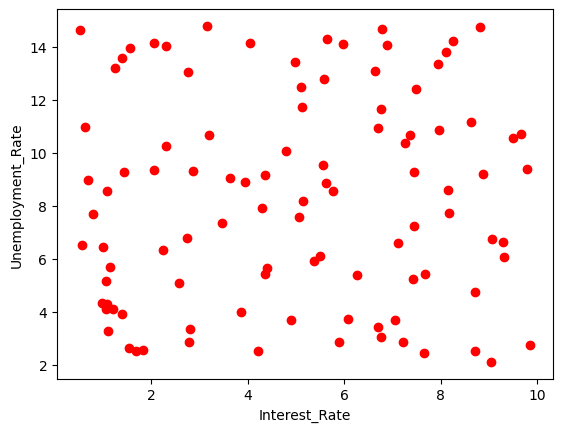

In [32]:
plt.scatter(df_index['Interest_Rate'] , df_index['Unemployment_Rate'] , color = 'r' )
plt.xlabel('Interest_Rate')
plt.ylabel('Unemployment_Rate')
plt.show()

In [34]:
###Independent and Independent Features

x = df_index[['Interest_Rate','Unemployment_Rate']]  ###or df_index.iloc[:,:-1]

y = df_index['Index_Price']


In [35]:
from sklearn.model_selection import train_test_split

x_train , x_test , y_train , y_test = train_test_split(x,y,test_size = 0.3 , random_state = 42)

In [36]:
x_train.shape

(70, 2)

In [37]:
x_test.shape

(30, 2)

<Axes: xlabel='Interest_Rate', ylabel='Index_Price'>

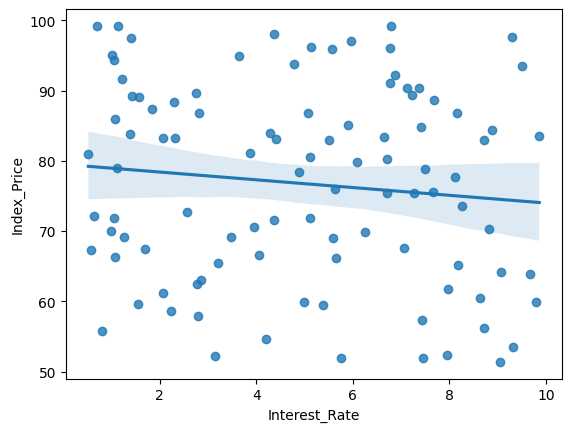

In [38]:
import seaborn as sns

sns.regplot(x = 'Interest_Rate' , y = 'Index_Price' , data = df_index)

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)

x_test= scaler.transform(x_test)

In [42]:
x_train

array([[ 1.85593101,  0.3170979 ],
       [-0.61170775, -1.21808734],
       [ 1.68270136, -0.38209537],
       [ 0.08828147,  0.48682961],
       [-0.792008  ,  1.48748665],
       [-0.62584895,  1.24428899],
       [ 0.12363446, -1.12942152],
       [-0.8132198 , -0.46062795],
       [ 0.94735915, -1.33461955],
       [-0.87331988,  0.30189805],
       [-0.06020109, -0.68862576],
       [-1.40361475, -0.40996177],
       [ 0.47716437, -1.33715286],
       [-1.23038509, -1.02555585],
       [ 1.59431888, -1.52968434],
       [ 1.80997212,  0.64642807],
       [ 1.60138948, -0.35929559],
       [ 0.82715898,  1.5001532 ],
       [-0.78493741,  0.52989586],
       [-1.00766125, -1.42835198],
       [-0.08848349, -0.05529852],
       [ 1.88067811, -1.37261918],
       [ 0.342823  , -0.51889406],
       [-1.32230287, -0.11609793],
       [-1.16321441,  1.27722201],
       [-0.06373639,  0.2588318 ],
       [-0.61877835, -1.33461955],
       [-0.95816706, -1.41568544],
       [-1.23038509,

In [43]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(x_train , y_train)



LinearRegression()

In [46]:
#Cross Validation

from sklearn.model_selection import cross_val_score

score = cross_val_score(lr , x_train , y_train , scoring = 'neg_mean_squared_error' , cv = 5)

print(score)

[-239.93348692 -202.09777582 -213.0094027  -189.98889386 -178.82970851]


In [47]:
np.mean(score)

-204.77185355916072

In [48]:
##Predicition

y_pred = lr.predict(x_test)

In [49]:
y_pred

array([79.12832969, 75.32920084, 75.29314221, 74.67856294, 75.61333235,
       76.51580926, 73.85831492, 72.95283931, 76.25162447, 75.7480179 ,
       74.59404688, 75.87939712, 77.20014738, 74.20762795, 76.12965452,
       74.77313462, 73.31029071, 76.22931923, 75.95379228, 77.55042366,
       76.76166642, 74.61003154, 77.73500227, 76.90788995, 74.53560847,
       74.81535847, 75.05398461, 76.03105869, 74.66590634, 73.91675024])

In [53]:
from sklearn.metrics import mean_squared_error , r2_score , accuracy_score

mse = mean_squared_error(y_test , y_pred)
r2_score = r2_score(y_test , y_pred)

print(mse)
print(r2_score)


180.89879497679087
-0.04453227983157393


In [54]:
residuals = y_test - y_pred
print(residuals)

83     1.831670
53     7.840799
70   -14.783142
45     9.661437
44    14.716668
39    18.464191
22    -6.298315
80     9.987161
10    -2.721624
0     20.471982
18    -4.674047
30     3.150603
73   -11.090147
33     5.622372
90   -23.819655
4     11.976865
76     2.249709
77    13.460681
12    19.966208
31    21.629576
55    18.238334
88    15.719968
26   -11.175002
42    -5.107890
69    -9.345608
15    18.754642
40   -15.553985
96     2.748941
9    -22.725906
72     6.413250
Name: Index_Price, dtype: float64


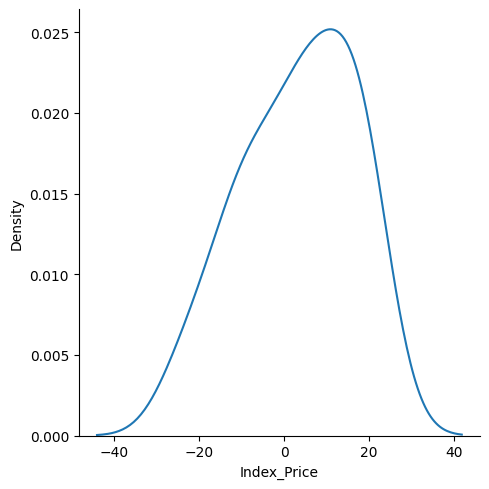

In [55]:
sns.displot(residuals , kind = 'kde')

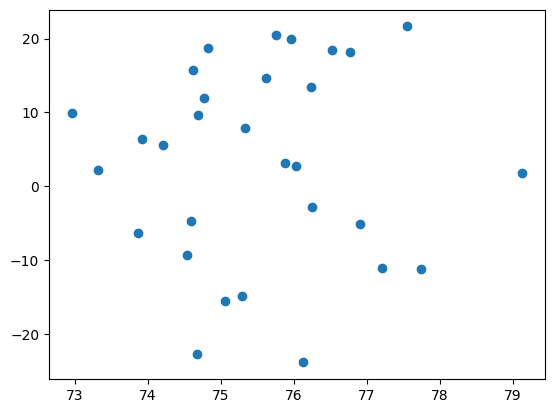

In [56]:
### Scatter plot wrt to Prediction and Residuals

plt.scatter(y_pred , residuals)

In [57]:
import statsmodels.api as sm


model = sm.OLS(y_train,x_train).fit()

In [59]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:            Index_Price   R-squared (uncentered):                   0.000
Model:                            OLS   Adj. R-squared (uncentered):             -0.029
Method:                 Least Squares   F-statistic:                            0.01127
Date:                Sun, 19 Jan 2025   Prob (F-statistic):                       0.989
Time:                        06:04:26   Log-Likelihood:                         -403.58
No. Observations:                  70   AIC:                                      811.2
Df Residuals:                      68   BIC:                                      815.7
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [60]:
print(lr.coef_)

[-1.01345683  1.05735598]
